
# Category & Genre Distribution Analysis  
Using **indie.csv** and **notindie.csv**

This notebook analyzes **category and genre distributions** across Steam, Epic, and IGDB for indie vs non‑indie games.


In [1]:

import ast
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 200)

def parse_list(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
    except:
        return []


## Load Data

In [2]:
indie_path = '../data/gold/indie.csv'
notindie_path = '../data/gold/notindie.csv'
indie = pd.read_csv(indie_path)
notindie = pd.read_csv(notindie_path)

# Parse category/genre list-like columns
for df in [indie, notindie]:
    for col in ["categories_steam", "categories_epic", "categories_igdb"]:
        if col in df.columns:
            df[col] = df[col].apply(parse_list)


## Combine Categories Across Platforms

In [3]:

def merge_categories(row):
    c = []
    for col in ["categories_steam","categories_epic","categories_igdb"]:
        if col in row:
            c.extend(row[col] if isinstance(row[col], list) else [])
    return [x for x in c if isinstance(x, str)]

indie["all_categories"] = indie.apply(merge_categories, axis=1)
notindie["all_categories"] = notindie.apply(merge_categories, axis=1)

indie.head(3)


,Unnamed: 0,id,steam_ID,epic_ID,igdb_ID,title,platform,developers,publishers_steam,publishers_epic,...,categories_epic,categories_igdb,effective_date_steam,effective_date_epic,effective_date_igdb,price_steam,price_epic,discount_percent_steam,discount_percent_epic,all_categories
0,1,2,2556940.0,NaN,NaN,! shakabula *,['steam'],['Skermunkel'],['Skermunkel'],NaN,...,[],[],2023-10-13,NaN,NaN,13.88,NaN,0.0,NaN,"[Single-player, Full controller support, Steam Cloud, Family Sharing, Action, Indie, RPG, Early Access]"
1,2,3,449940.0,NaN,NaN,! that bastard is trying to steal our gold !,['steam'],['WTFOMGames'],['WTFOMGames'],NaN,...,[],[],2016-03-03,NaN,NaN,2.77,NaN,0.0,NaN,"[Single-player, Steam Trading Cards, Partial Controller Support, Family Sharing, Action, Adventure, Casual, Indie]"
2,4,5,866510.0,NaN,NaN,!anyway!,['steam'],['EYEFRONT'],['EYEFRONT'],NaN,...,[],[],2018-06-06,NaN,NaN,1.84,NaN,0.0,NaN,"[Single-player, Multi-player, Steam Achievements, Full controller support, Steam Trading Cards, Steam Workshop, In-App Purchases, Playable without Timed Input, Save Anytime, Steam Cloud, Stats, St..."


## Count Category Frequency

In [12]:

from collections import Counter

NOISE_KEYWORDS = ["steam", "cloud", "trading", "vr", "co-op", "coop", "local", "achieve", "games"]

def clean_cat(cat):
    if isinstance(cat, str):
        text = cat.lower()
        return not any(key in text for key in NOISE_KEYWORDS)
    return False

# Remove any category containing 'steam'
indie_filtered_cats = [
    cat for row in indie["all_categories"] for cat in row if clean_cat(cat)
]

not_filtered_cats = [
    cat for row in notindie["all_categories"] for cat in row if clean_cat(cat)
]

# Recount after filtering
indie_cat_counts = Counter(indie_filtered_cats)
not_cat_counts   = Counter(not_filtered_cats)

# Build top-20 dataframes
indie_cat_df = pd.DataFrame(indie_cat_counts.most_common(20), columns=["Category","Count"])
not_cat_df   = pd.DataFrame(not_cat_counts.most_common(20), columns=["Category","Count"])

indie_cat_df



,Category,Count
0,Indie,91916
1,Single-player,49043
2,Family Sharing,46690
3,Adventure,39135
4,Action,23348
5,Casual,22794
6,Strategy,18259
7,Full controller support,13201
8,Simulation,10719
9,RPG,9606


## Top 20 Indie Categories (Bar Plot)

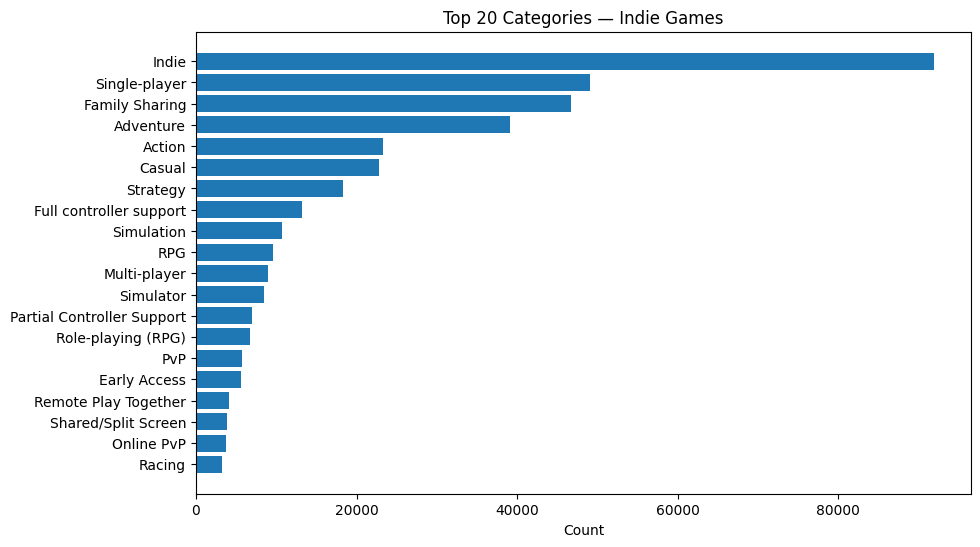

In [13]:

plt.figure(figsize=(10,6))
plt.barh(indie_cat_df["Category"], indie_cat_df["Count"])
plt.xlabel("Count")
plt.title("Top 20 Categories — Indie Games")
plt.gca().invert_yaxis()
plt.show()


## Top 20 Non‑Indie Categories (Bar Plot)

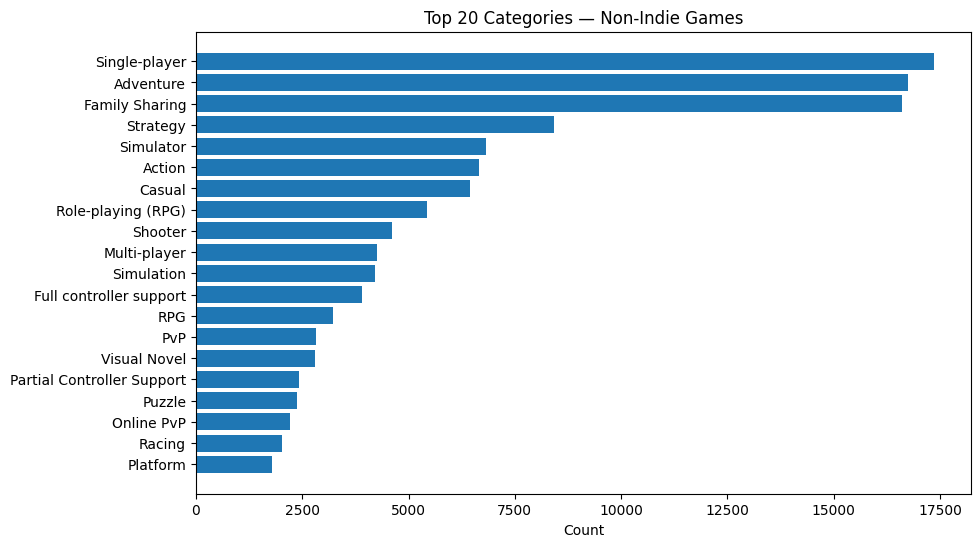

In [14]:

plt.figure(figsize=(10,6))
plt.barh(not_cat_df["Category"], not_cat_df["Count"])
plt.xlabel("Count")
plt.title("Top 20 Categories — Non‑Indie Games")
plt.gca().invert_yaxis()
plt.show()


## Compare Category Overlap

In [15]:

# overlap measure
indie_cats = set(indie_cat_counts.keys())
not_cats = set(not_cat_counts.keys())

common = indie_cats & not_cats
unique_indie = indie_cats - not_cats
unique_not = not_cats - indie_cats

summary = {
    "Total Indie Categories": len(indie_cats),
    "Total Non‑Indie Categories": len(not_cats),
    "Common Categories": len(common),
    "Indie‑Only": len(unique_indie),
    "Non‑Indie Only": len(unique_not)
}

pd.Series(summary)


Total Indie Categories        90
Total Non‑Indie Categories    87
Common Categories             87
Indie‑Only                     3
Non‑Indie Only                 0
dtype: int64

In [10]:
print(unique_indie)

{'Short', 'Indie', 'Movie'}


## Top Shared Categories Between Indie & Non‑Indie

In [16]:

shared_freq = {
    cat: indie_cat_counts[cat] + not_cat_counts[cat]
    for cat in common
}
shared_df = pd.DataFrame(sorted(shared_freq.items(), key=lambda x: -x[1])[:20],
                         columns=["Category","Total Count"])
shared_df


,Category,Total Count
0,Single-player,66404
1,Family Sharing,63295
2,Adventure,55884
3,Action,30012
4,Casual,29240
5,Strategy,26690
6,Full controller support,17115
7,Simulator,15365
8,Simulation,14923
9,Multi-player,13281


## Shared Category Distribution (Bar Plot)

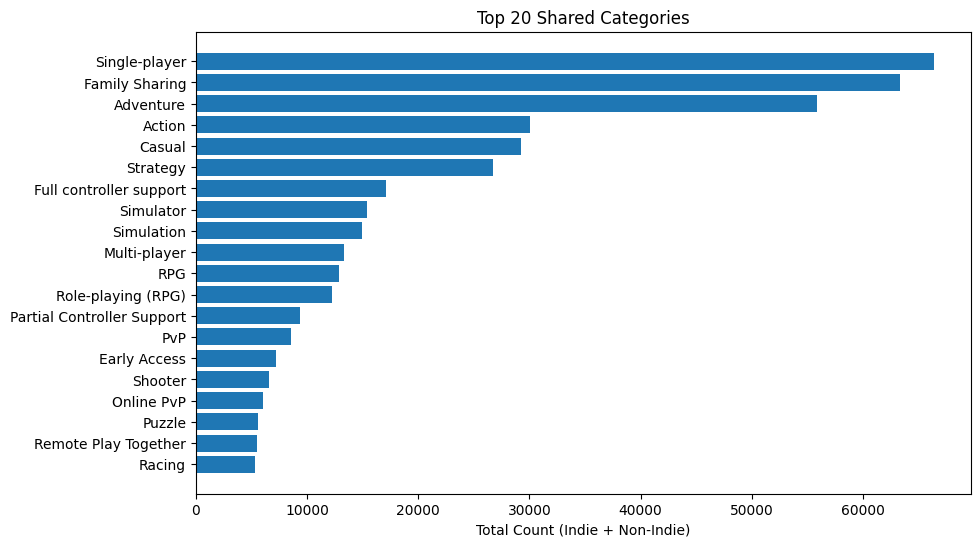

In [17]:

plt.figure(figsize=(10,6))
plt.barh(shared_df["Category"], shared_df["Total Count"])
plt.xlabel("Total Count (Indie + Non‑Indie)")
plt.title("Top 20 Shared Categories")
plt.gca().invert_yaxis()
plt.show()
